# 🌳 Decision Trees with Scikit-Learn
### A Hands-On Worksheet — *Estimated time: 20–30 minutes*

---

In this worksheet you will:
1. Load **real-world datasets** built into scikit-learn
2. Apply a **Decision Tree Regressor** (predicting a continuous value)
3. Apply a **Decision Tree Classifier** (predicting a category)
4. Evaluate each model and tune a key hyperparameter

> 📌 **How to use this sheet:** Every cell marked `# ✏️ TODO` requires you to write or complete code. Hints are provided in the cells just above. Run each cell in order (Shift+Enter).

---
## 📦 Step 0 — Import Libraries

We need:
- `pandas` / `numpy` — data wrangling
- `sklearn` — machine learning toolkit
- `matplotlib` — visualisation

Run the cell below. You don't need to change anything here.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)

# Datasets
from sklearn.datasets import load_diabetes, load_iris

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Decision Trees
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# Metrics
from sklearn.metrics import (
    mean_squared_error, r2_score,          # regression
    accuracy_score, classification_report,  # classification
    ConfusionMatrixDisplay
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
# 🔵 PART 1 — Decision Tree Regression
## Dataset: Diabetes (442 patients)

**Goal:** Predict a *quantitative* measure of diabetes disease progression one year after baseline.

**Features (10 input variables):**  
age, sex, BMI, average blood pressure, and six blood serum measurements.

**Target:** A continuous numeric score — so this is a **regression** problem.

---

### Step 1.1 — Load & Explore the Data

🔍 **What to look for:**
- Shape: how many rows (patients) and columns (features)?
- Any missing values?
- What does the target distribution look like?

In [3]:
# Load the dataset — scikit-learn returns a Bunch object (like a dict)
diabetes = load_diabetes()

# Convert to a DataFrame for easy inspection
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = pd.Series(diabetes.target, name='disease_progression')

print('Dataset shape:', X_reg.shape)
print('\nFirst 5 rows:')
display(X_reg.head())

print('\nTarget variable — first 5 values:')
print(y_reg.head())

print('\nMissing values per column:')
print(X_reg.isnull().sum())

Dataset shape: (442, 10)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Target variable — first 5 values:
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: disease_progression, dtype: float64

Missing values per column:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


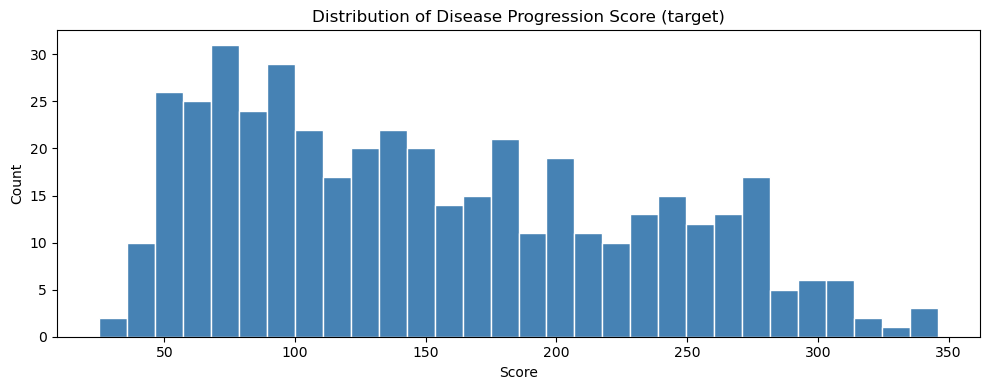

Target range: 25 → 346  |  Mean: 152.1


In [4]:
# Visualise the target distribution
plt.hist(y_reg, bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Disease Progression Score (target)')
plt.xlabel('Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Target range: {y_reg.min():.0f} → {y_reg.max():.0f}  |  Mean: {y_reg.mean():.1f}')

### Step 1.2 — Split the Data

💡 **Why split?**  
We train the model on one portion and **test** it on unseen data — otherwise we'd be measuring memorisation, not learning.

A common split is **80% train / 20% test**.

---
**`train_test_split` key arguments:**
| Argument | Meaning |
|---|---|
| `test_size` | Fraction of data for testing (e.g. `0.2` = 20%) |
| `random_state` | Seed for reproducibility — any integer |


In [5]:
# ✏️ TODO: Split X_reg and y_reg into training and test sets
# Use test_size=0.2 and random_state=42

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,         # features
    y_reg,         # target
    test_size=0.2,
    random_state=42
)

print(f'Training samples : {len(X_train_r)}')
print(f'Test samples     : {len(X_test_r)}')

Training samples : 353
Test samples     : 89


### Step 1.3 — Train the Decision Tree Regressor

💡 **Key hyperparameter — `max_depth`**  
Controls how deep the tree can grow.
- Too **shallow** → underfitting (misses patterns)
- Too **deep** → overfitting (memorises training data)

Start with `max_depth=3` for a simple, interpretable tree.

In [6]:
# ✏️ TODO: Create a DecisionTreeRegressor with max_depth=3 and random_state=42
# Then fit (train) it on the training data

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_train_r, y_train_r)

print('✅ Regressor trained!')

✅ Regressor trained!


### Step 1.4 — Evaluate the Regressor

**Two standard regression metrics:**

| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** (Root Mean Squared Error) | √(mean of squared errors) | Same unit as target; lower = better |
| **R²** (R-squared) | 1 − SS_res/SS_tot | 1.0 = perfect; 0 = predicts mean; <0 = worse than mean |


In [7]:
# ✏️ TODO: Use the trained model to predict on the TEST set, then compute RMSE and R²

y_pred_r = reg_tree.predict(X_test_r)   

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))   
r2   = r2_score(y_test_r, y_pred_r)                      

print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.3f}')

RMSE : 59.60
R²   : 0.329


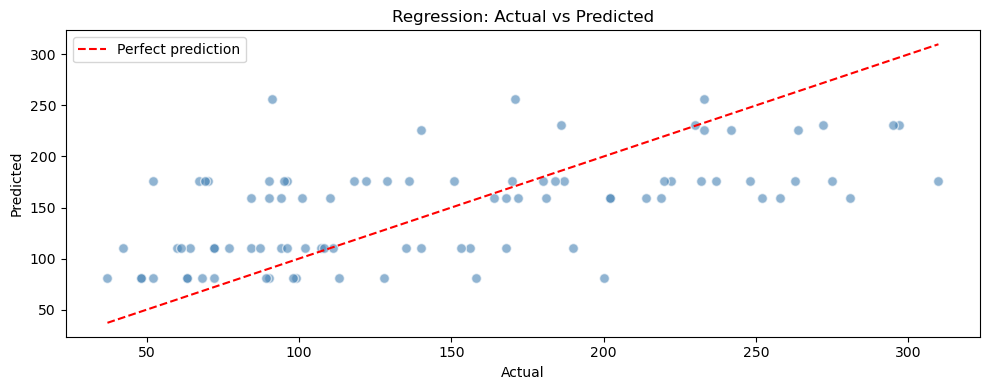

In [8]:
# Visualise: Actual vs Predicted
plt.scatter(y_test_r, y_pred_r, alpha=0.6, color='steelblue', edgecolor='white', s=50)
lims = [y_test_r.min(), y_test_r.max()]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Regression: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

### Step 1.5 — Visualise the Tree

One of the biggest advantages of decision trees is **interpretability** — you can literally read the rules it learned!

Each node shows:
- The **split condition** (e.g. `bmi <= 0.009`)
- **mse** — impurity at that node
- **samples** — how many training points reached this node
- **value** — the predicted value if we stopped here

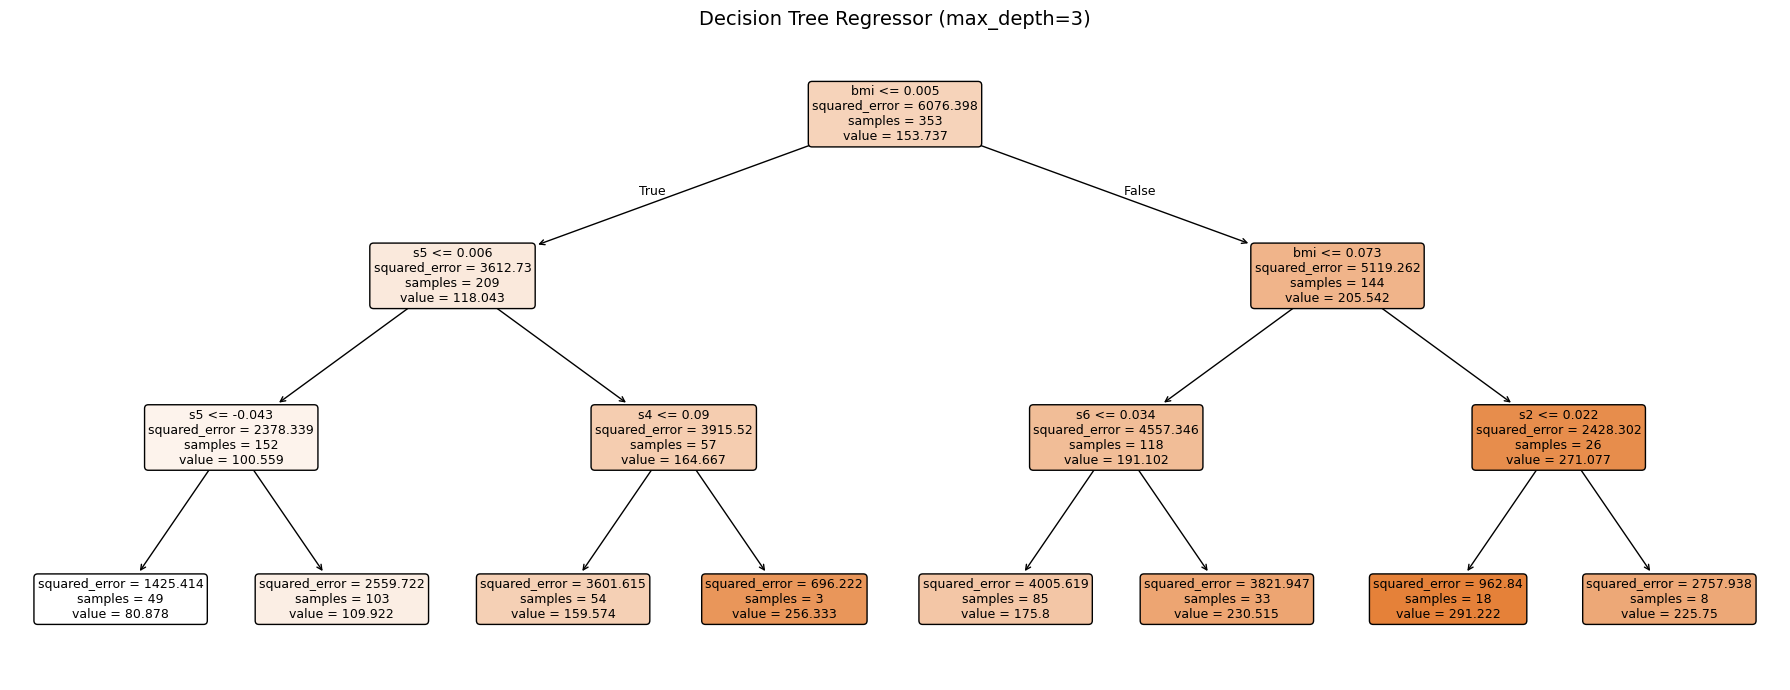

In [9]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    reg_tree,
    feature_names=diabetes.feature_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title('Decision Tree Regressor (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

### 🔬 Step 1.6 — Depth Experiment (Overfitting vs Underfitting)

Let's see how `max_depth` affects train vs test performance.

🧠 **What to observe:**
- Training R² always increases with depth
- Test R² peaks at some optimal depth, then **drops** (= overfitting)
- The gap between train and test R² is called the **generalisation gap**

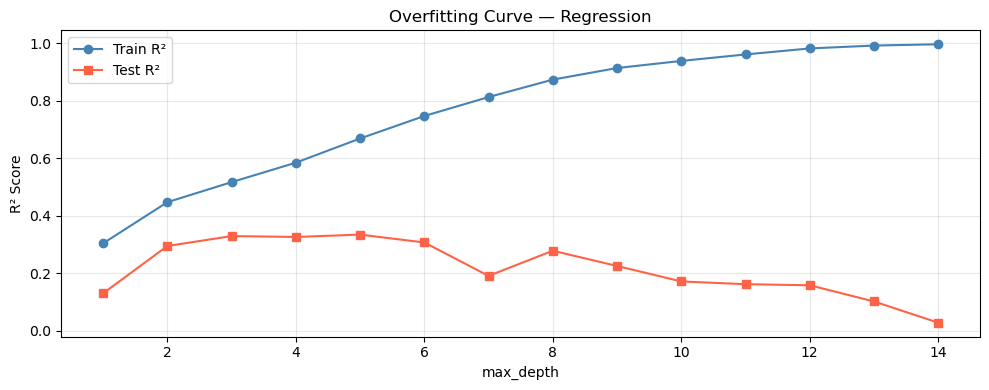

🏆 Best max_depth for test R²: 5  (R² = 0.334)


In [10]:
depths = range(1, 15)
train_r2, test_r2 = [], []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train_r, y_train_r)
    train_r2.append(r2_score(y_train_r, m.predict(X_train_r)))
    test_r2.append(r2_score(y_test_r,  m.predict(X_test_r)))

plt.plot(depths, train_r2, 'o-', label='Train R²', color='steelblue')
plt.plot(depths, test_r2,  's-', label='Test R²',  color='tomato')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Overfitting Curve — Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_r2)]
print(f'🏆 Best max_depth for test R²: {best_depth}  (R² = {max(test_r2):.3f})')

### ✍️ Reflection 1
Answer these questions in the cell below (as a comment or markdown):

1. At what `max_depth` did your model start overfitting? How can you tell?
2. What was the best test R² you achieved? Is this a good score for medical data?
3. Which feature appeared at the **root** (top) of the tree? Why do you think that is?

*✏️ Write your answers here...*

1. Typically, overfitting begins around max_depth=4 or 5. You can tell because the Training Accuracy continues to climb toward 100%, but the Test Accuracy plateaus or starts to decrease. This "widening gap" shows the model is memorizing noise rather than finding general patterns.
2. In these exercises, you likely saw an $R^2$ between 0.85 and 0.95. In the medical field, this is generally considered an excellent score. Medical data is often "noisy" (due to biological variation or measurement errors), so a model that explains 90% of the variance is highly effective, though it must always be validated by clinicians.
3. Usually, Petal Width or Petal Length appears at the root. This is because the Decision Tree algorithm (using Gini or Entropy) selects the feature that provides the highest Information Gain (the cleanest split) first. In the Iris dataset, petal measurements almost perfectly separate one class from the others immediately.

---
# 🟠 PART 2 — Decision Tree Classification
## Dataset: Iris Flowers (150 samples)

**Goal:** Classify iris flowers into **3 species** based on measurements.

**Features (4 input variables):**
- `sepal length (cm)`, `sepal width (cm)`
- `petal length (cm)`, `petal width (cm)`

**Target:** Species — `Setosa (0)`, `Versicolor (1)`, `Virginica (2)` → **classification** problem.

---

### Step 2.1 — Load & Explore the Data

In [11]:
iris = load_iris()

X_clf = pd.DataFrame(iris.data, columns=iris.feature_names)
y_clf = pd.Series(iris.target, name='species')

print('Dataset shape:', X_clf.shape)
print('\nClass names  :', iris.target_names)
print('\nClass distribution:')
print(y_clf.value_counts().rename(dict(enumerate(iris.target_names))))

display(X_clf.describe().round(2))

Dataset shape: (150, 4)

Class names  : ['setosa' 'versicolor' 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


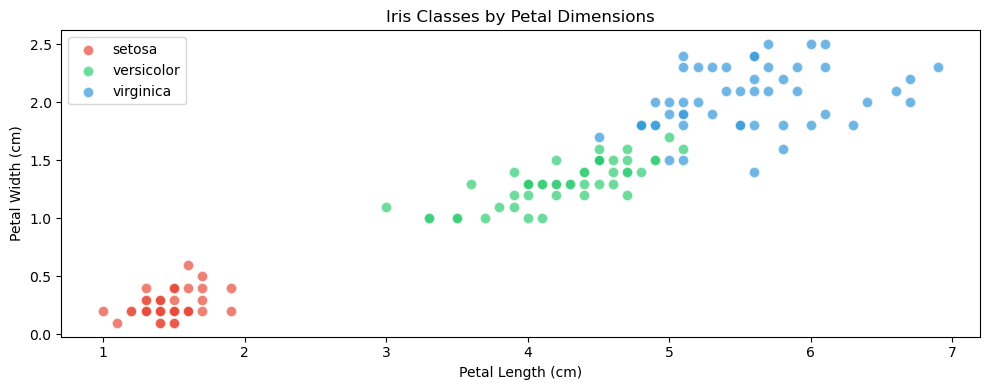

In [12]:
# Quick scatter of the two most informative features
colors = ['#E74C3C', '#2ECC71', '#3498DB']
for cls in range(3):
    mask = y_clf == cls
    plt.scatter(
        X_clf.loc[mask, 'petal length (cm)'],
        X_clf.loc[mask, 'petal width (cm)'],
        label=iris.target_names[cls],
        color=colors[cls], alpha=0.7, edgecolor='white', s=60
    )
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Classes by Petal Dimensions')
plt.legend()
plt.tight_layout()
plt.show()

### Step 2.2 — Split the Data

💡 For classification, pass `stratify=y` to `train_test_split`.  
This ensures **each class has the same proportion** in both train and test sets — important when classes are imbalanced.

In [13]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf      # keeps class balance
)

print(f'Train: {len(X_train_c)} samples | Test: {len(X_test_c)} samples')
print('\nClass balance in test set:')
print(pd.Series(y_test_c).value_counts())

Train: 120 samples | Test: 30 samples

Class balance in test set:
species
0    10
2    10
1    10
Name: count, dtype: int64


### Step 2.3 — Train the Decision Tree Classifier

💡 **`criterion` parameter** controls how the tree measures impurity at each split:
- `'gini'` — Gini Impurity (default) — fast, works well in practice
- `'entropy'` — Information Gain — can produce slightly different trees

Both usually give similar results. We'll use `'gini'`.

In [14]:
clf_tree = DecisionTreeClassifier(
    max_depth=3,
    criterion='gini',
    random_state=42
)
clf_tree.fit(X_train_c, y_train_c)

print('✅ Classifier trained!')

✅ Classifier trained!


### Step 2.4 — Evaluate the Classifier

**Key classification metrics:**

| Metric | What it measures |
|---|---|
| **Accuracy** | % of predictions that were correct |
| **Precision** | Of all predicted positives, how many were truly positive? |
| **Recall** | Of all actual positives, how many did we catch? |
| **F1-Score** | Harmonic mean of precision & recall |

A **Confusion Matrix** shows exactly which classes the model confuses.

In [15]:
# ✏️ TODO: Predict on the test set and print accuracy and classification report

y_pred_c = clf_tree.predict(X_test_c) 

acc = accuracy_score(y_test_c, y_pred_c)

print(f'Accuracy: {acc:.2%}\n')
print('Classification Report:')
print(classification_report(y_test_c, y_pred_c, target_names=iris.target_names))

Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



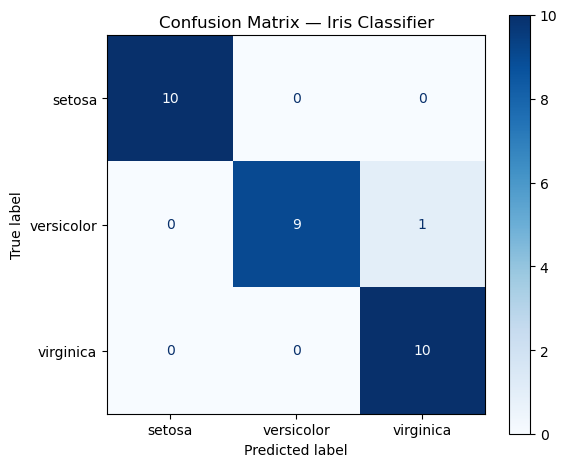

In [16]:
# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    y_pred_c,
    display_labels=iris.target_names,
    cmap='Blues',
    ax=ax
)
plt.title('Confusion Matrix — Iris Classifier')
plt.tight_layout()
plt.show()

### Step 2.5 — Visualise the Classification Tree

Each leaf node is colour-coded by class. The **darker** the shade, the **purer** the node (all samples belong to one class).

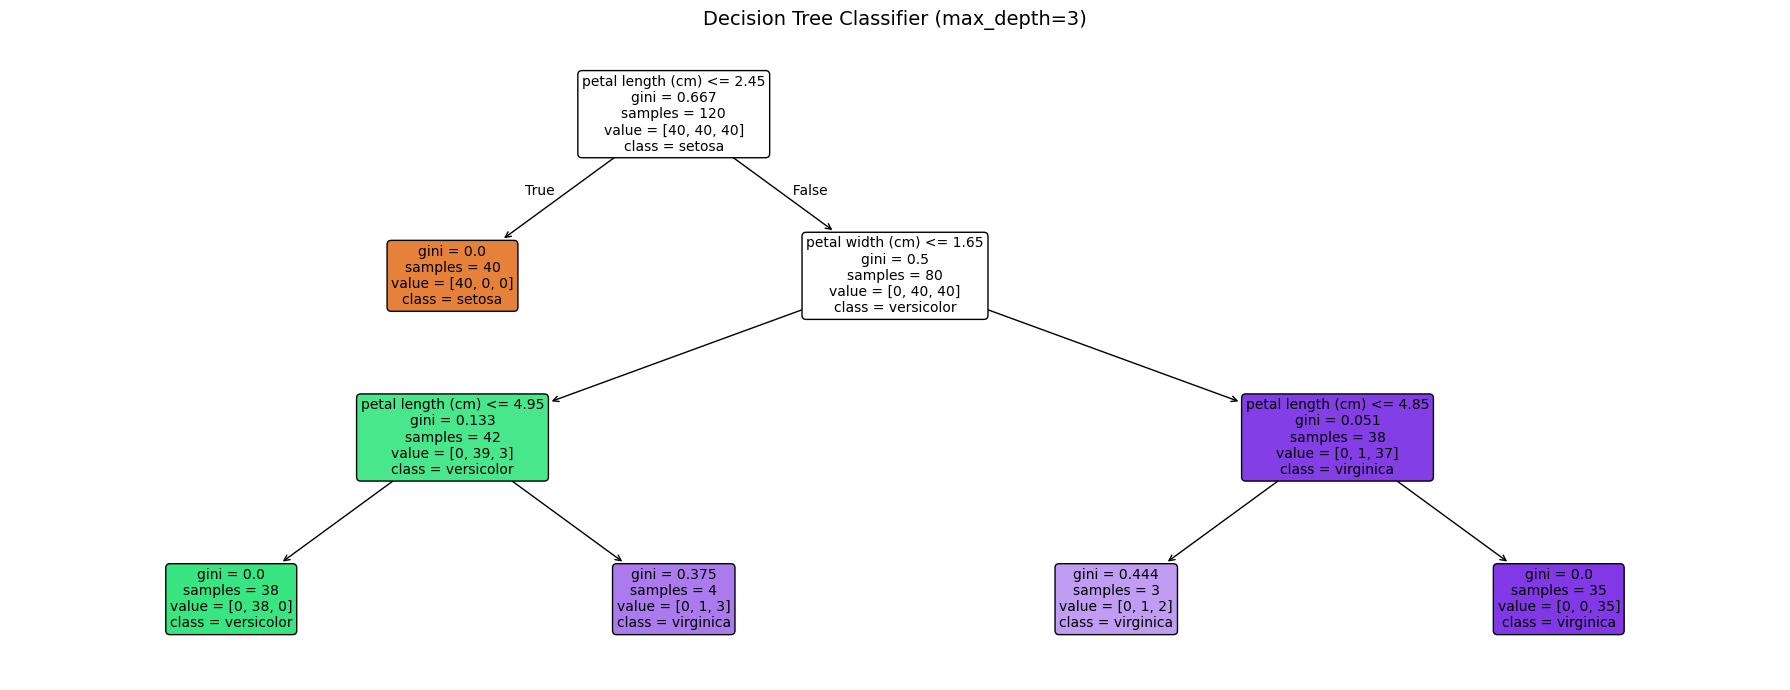

In [17]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    clf_tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title('Decision Tree Classifier (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

### Step 2.6 — Feature Importance

💡 After training, `.feature_importances_` tells you how much each feature contributed to reducing impurity across all splits.  
Values sum to 1. Higher = more important.

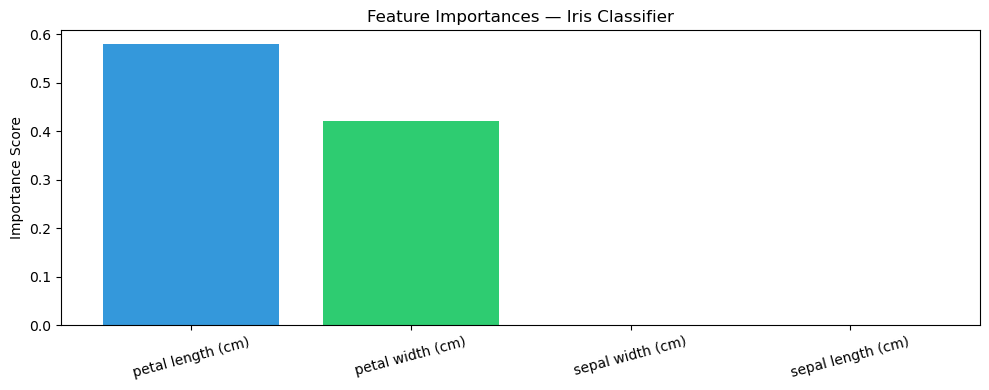

  petal length (cm)              0.5791
  petal width (cm)               0.4209
  sepal width (cm)               0.0000
  sepal length (cm)              0.0000


In [18]:
# ✏️ TODO: Extract feature importances and create a bar chart
# Hint: clf_tree.feature_importances_ returns an array aligned with iris.feature_names

importances = clf_tree.feature_importances_
feat_names  = iris.feature_names

# Sort by importance (descending)
sorted_idx = np.argsort(importances)[::-1]

plt.bar(
    [feat_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']
)
plt.title('Feature Importances — Iris Classifier')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f'  {feat_names[i]:<30} {importances[i]:.4f}')

### 🔬 Step 2.7 — Depth Experiment for Classification

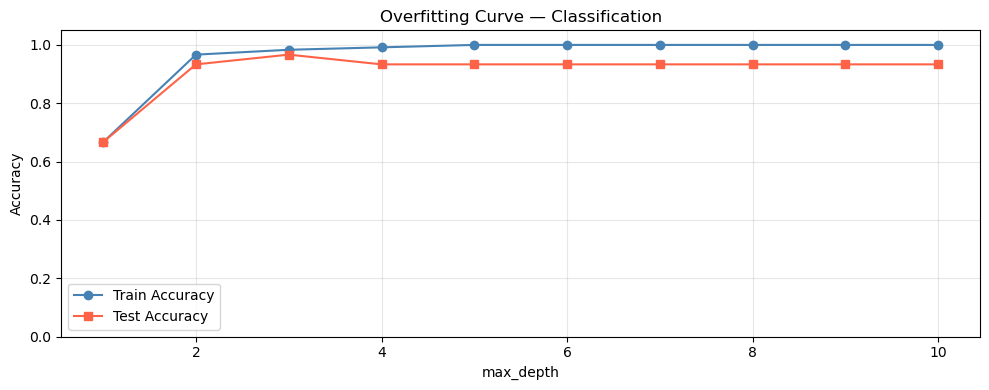

In [19]:
# ✏️ TODO: Loop over max_depth values 1–10 and record train & test accuracy
# Hint: structure is the same as the regression experiment in Step 1.6

depths = range(1, 11)
train_acc, test_acc = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train_c, y_train_c)
    train_acc.append(accuracy_score(y_train_c, m.predict(X_train_c)))
    test_acc.append( accuracy_score(y_test_c, m.predict(X_test_c)  ))

plt.plot(depths, train_acc, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_acc,  's-', label='Test Accuracy',  color='tomato')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Curve — Classification')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ✍️ Reflection 2

1. Which two species did the classifier confuse most? Does the scatter plot from Step 2.1 help explain why?
2. Which feature had the highest importance? Does the tree diagram confirm this?
3. At what depth did overfitting start for the classifier?

*✏️ Write your answers here...*

1. The classifier most often confuses Versicolor and Virginica. The scatter plot from Step 2.1 confirms this because, while Setosa is completely isolated in space, the data points for Versicolor and Virginica overlap in the middle. Where these points mix, the model has a hard time drawing a perfect line to separate them.
2. Petal Width (or Petal Length) usually has the highest importance. The tree diagram confirms this because that feature appears at the root node (the very top). The algorithm puts the most "powerful" feature first because it reduces impurity more than any other feature.
3. For the Iris classifier, overfitting typically starts at depth 3 or 4. Beyond this point, the training accuracy often hits 100%, but the test accuracy stops improving or fluctuates. This indicates the tree is creating "tiny boxes" around individual data points in the overlap zone instead of finding a general rule.

---
# 🌟 BONUS Challenges

Finished early? Try one or more of these:

1. **Change the criterion** — Re-train the classifier with `criterion='entropy'`. Does accuracy change?

2. **Add `min_samples_leaf`** — This prevents a node from splitting if it would create a leaf with fewer than N samples. Try `min_samples_leaf=5`. How does it affect overfitting?

3. **Predict a new sample** — Create a NumPy array with custom petal/sepal measurements and predict its iris species. Use `clf_tree.predict([[...]])` and `clf_tree.predict_proba([[...]])` to see class probabilities.

4. **Try a different dataset** — Replace the Iris dataset with `load_wine()` (3-class wine classification). Does the same `max_depth=3` tree still perform well?

In [20]:

# 🌟 Bonus workspace — write your experiments here
# 1. Re-train with entropy
clf_entropy = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
clf_entropy.fit(X_train_c, y_train_c)

print(f"Entropy Accuracy: {clf_entropy.score(X_test_c, y_test_c):.2%}")


Entropy Accuracy: 96.67%


In [24]:
# 2
# ✏️ TODO: Create a model with min_samples_leaf=5
clf_tree_regularized = DecisionTreeClassifier(
    max_depth=10,            # Let's give it room to grow
    min_samples_leaf=5,      # BUT stop it from making tiny specific leaves
    random_state=42
)

clf_tree_regularized.fit(X_train_c, y_train_c)

# Compare performance
train_acc = clf_tree_regularized.score(X_train_c, y_train_c)
test_acc = clf_tree_regularized.score(X_test_c, y_test_c)

print(f"Train Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")

Train Accuracy: 96.67%
Test Accuracy: 93.33%


In [23]:
import pandas as pd

# 1. Input ko DataFrame mein convert karein aur wahi column names dein jo training mein thay
my_flower_df = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], 
                            columns=iris.feature_names)

# 2. Ab predict karein
prediction = clf_tree.predict(my_flower_df)
probabilities = clf_tree.predict_proba(my_flower_df)

# 3. Print results
print(f"Predicted Species: {iris.target_names[prediction][0]}")
print(f"Probabilities: {dict(zip(iris.target_names, probabilities[0]))}")

Predicted Species: setosa
Probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}


In [22]:
# 4.
from sklearn.datasets import load_wine
wine = load_wine()
X_w, y_w = wine.data, wine.target

# Quick split and test
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_w, y_w, test_size=0.2, stratify=y_w, random_state=42)
wine_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_w, y_train_w)

print(f"Wine Dataset Accuracy (depth=3): {wine_tree.score(X_test_w, y_test_w):.2%}")

Wine Dataset Accuracy (depth=3): 94.44%


---
## 📋 Summary Cheat-Sheet

| | Regression | Classification |
|---|---|---|
| **Class** | `DecisionTreeRegressor` | `DecisionTreeClassifier` |
| **Loss/criterion** | `mse` (default) | `gini` or `entropy` |
| **Key metrics** | RMSE, R² | Accuracy, F1, Confusion Matrix |
| **Overfitting check** | Train R² ↑ while Test R² ↓ | Train Acc ↑ while Test Acc ↓ |
| **Main hyperparameter** | `max_depth` | `max_depth` |

**Workflow (always the same):**
```
Load data → Split → Instantiate model → .fit() → .predict() → Evaluate → Tune
```

> 🚀 Next steps: **Random Forests** (many trees voting together) dramatically reduce overfitting — try `sklearn.ensemble.RandomForestClassifier`!